In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
os.makedirs('/content/drive/My Drive/fMRI_Project', exist_ok=True)
os.makedirs('/content/drive/My Drive/fMRI_Project/data', exist_ok=True)
os.makedirs('/content/drive/My Drive/fMRI_Project/results', exist_ok=True)
os.makedirs('/content/drive/My Drive/fMRI_Project/models', exist_ok=True)

print(" Folders ready!")

 Folders ready!


In [ ]:
!pip install numpy scipy matplotlib scikit-learn nibabel nilearn
print(" Sab install ho gaya!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 135.6 MB/s eta 0:00:00
 Sab install ho gaya!


In [ ]:
from nilearn import datasets
import numpy as np

print(" fMRI data download ho raha hai...")

 fMRI data download ho raha hai...


In [ ]:
import numpy as np
from nilearn import datasets
import matplotlib.pyplot as plt

print(" Demo fMRI data is downloading...")

 Demo fMRI data is downloading...


In [ ]:
adhd = datasets.fetch_adhd(n_subjects=1)

print(f" Data is downloaded")
print(f"   Available files: {adhd.keys()}")

[fetch_adhd] Added README.md to /root/nilearn_data

[fetch_adhd] Dataset created in /root/nilearn_data/adhd

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7781/adhd40_metadata.tgz ...

[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/fbef5baff0b388a8c913a08e1d84e059/adhd40_metadata.tgz...

...

[fetch_adhd] Downloaded 39337984 of 44414948 bytes (88.6%%,    0.6s remaining)

[fetch_adhd]  ...done. (5 seconds, 0 min)

[fetch_adhd] Extracting data from /root/nilearn_data/adhd/e7ff5670bd594dcd9453e57b55d69dc9/adhd40_0010042.tgz...

[fetch_adhd] .. done.

 Data is downloaded
   Available files: dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])


In [ ]:
# fMRI data nikalo
fmri_file = adhd['func'][0]  # Pehla subject ka fMRI
print(f"   fMRI file: {fmri_file}")

   fMRI file: /root/nilearn_data/adhd/data/0010042/0010042_rest_tshift_RPI_voreg_mni.nii.gz


In [ ]:
# Nibabel se load karo (nifti format)
import nibabel as nib

fmri_nib = nib.load(fmri_file)
fmri_data = fmri_nib.get_fdata()

print(f" Data loaded! Shape: {fmri_data.shape}")
print(f"   Dimensions: {fmri_data.shape}")

 Data loaded! Shape: (61, 73, 61, 176)
   Dimensions: (61, 73, 61, 176)


In [ ]:
# Google Drive mein save kardeya
np.save('/content/drive/My Drive/fMRI_Project/data/fmri_raw.npy', fmri_data)
print(" Data saved")

 Data saved


# Synthetic fMRI and Preprocessing

In this section we generate a 4D synthetic fMRI volume, extract a central brain region, and flatten it into voxel-wise time series after standardization.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

print("Creating synthetic fMRI data...")

Creating synthetic fMRI data...


In [ ]:
# Synthetic brain data
n_voxels_x, n_voxels_y, n_voxels_z = 64, 64, 64
n_timepoints = 200

print(f"Size: {n_voxels_x}x{n_voxels_y}x{n_voxels_z} voxels")
print(f"Timepoints: {n_timepoints}")

Size: 64x64x64 voxels
Timepoints: 200


In [ ]:
# Random brain signal
fmri_data = np.random.randn(n_voxels_x, n_voxels_y, n_voxels_z, n_timepoints)

In [ ]:
# Smooth data to look more realistic
fmri_data = gaussian_filter(fmri_data, sigma=2)

print(f"Synthetic data created. Shape: {fmri_data.shape}")

Synthetic data created. Shape: (64, 64, 64, 200)


In [ ]:
# Add an activation pattern in a spherical region
center_x, center_y, center_z = 32, 32, 32
radius = 10

for i in range(n_voxels_x):
    for j in range(n_voxels_y):
        for k in range(n_voxels_z):
            dist = np.sqrt((i-center_x)**2 + (j-center_y)**2 + (k-center_z)**2)
            if dist < radius:
                fmri_data[i, j, k, :] += 2.0 * np.sin(2 * np.pi * 0.1 * np.arange(n_timepoints))

print("Activation pattern added.")

Activation pattern added.


In [ ]:
# Save data
np.save('/content/drive/My Drive/fMRI_Project/data/fmri_raw.npy', fmri_data)
print("Synthetic fMRI data saved to drive.")

Synthetic fMRI data saved to drive.


**Preprocess and Flatten fMRI**
Ye code fmri_raw.npy ko load karega, ek chhota region lega, normalize karega, aur 2D shape mein convert karega: (voxels, timepoints)

In [ ]:
import numpy as np

print("Loading raw fMRI data...")
fmri_data = np.load('/content/drive/My Drive/fMRI_Project/data/fmri_raw.npy')
print(f"Raw data shape: {fmri_data.shape}")

Loading raw fMRI data...
Raw data shape: (64, 64, 64, 200)


In [ ]:
# Expecting shape: (X, Y, Z, T)
nx, ny, nz, nt = fmri_data.shape
print(f"Spatial size: {nx}x{ny}x{nz}, Timepoints: {nt}")

print("Selecting central brain region...")
center_x, center_y, center_z = nx // 2, ny // 2, nz // 2
region_size = 16  # 16 voxels in each direction

x_start = center_x - region_size
x_end   = center_x + region_size
y_start = center_y - region_size
y_end   = center_y + region_size
z_start = center_z - region_size
z_end   = center_z + region_size

fmri_region = fmri_data[x_start:x_end, y_start:y_end, z_start:z_end, :]
print(f"Region shape: {fmri_region.shape}")

Spatial size: 64x64x64, Timepoints: 200
Selecting central brain region...
Region shape: (32, 32, 32, 200)


In [ ]:
# Flatten to (voxels, timepoints)
n_voxels = fmri_region.shape[0] * fmri_region.shape[1] * fmri_region.shape[2]
n_timepoints = fmri_region.shape[3]

fmri_flat = fmri_region.reshape(n_voxels, n_timepoints)
print(f"Flattened shape: {fmri_flat.shape}")

print("Normalizing voxel time series (zero mean, unit std)...")
mean_per_voxel = fmri_flat.mean(axis=1, keepdims=True)
std_per_voxel = fmri_flat.std(axis=1, keepdims=True) + 1e-6
fmri_flat = (fmri_flat - mean_per_voxel) / std_per_voxel

print("Saving preprocessed fMRI data...")
np.save('/content/drive/My Drive/fMRI_Project/data/fmri_preprocessed.npy', fmri_flat)

print("Done. Preprocessed fMRI saved.")
print(f"Global mean: {fmri_flat.mean():.4f}, std: {fmri_flat.std():.4f}")

Flattened shape: (32768, 200)
Normalizing voxel time series (zero mean, unit std)...
Saving preprocessed fMRI data...
Done. Preprocessed fMRI saved.
Global mean: -0.0000, std: 1.0000


# Noise Modeling (Cardiac, Respiratory, Thermal)

We simulate three realistic fMRI noise sources: cardiac pulsation, respiratory motion, and thermal scanner noise. Each noise component is generated separately and then added to the preprocessed fMRI time series to obtain a noisy fMRI dataset that better matches real acquisition characteristics.


**Cardiac noise model**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Building cardiac noise model...")

class CardiacNoiseModel:
    def __init__(self, cardiac_rate_bpm=70):
        self.cardiac_rate_bpm = cardiac_rate_bpm
        self.cardiac_freq_hz = cardiac_rate_bpm / 60.0  # Hz

    def generate(self, n_timepoints, tr=1.0):
        t = np.arange(n_timepoints) * tr
        f0 = self.cardiac_freq_hz
        signal = (
            0.5 * np.sin(2 * np.pi * f0 * t) +
            0.3 * np.sin(2 * np.pi * 2 * f0 * t) +
            0.15 * np.sin(2 * np.pi * 3 * f0 * t)
        )
        return signal

    def power_spectrum(self, x, tr=1.0):
        n = len(x)
        freqs = np.fft.fftfreq(n, d=tr)
        power = np.abs(np.fft.fft(x))**2
        return freqs, power

Building cardiac noise model...


In [ ]:
# load time dimension
fmri_flat = np.load('/content/drive/My Drive/fMRI_Project/data/fmri_preprocessed.npy')
n_voxels, n_timepoints = fmri_flat.shape

cardiac = CardiacNoiseModel(cardiac_rate_bpm=70)
cardiac_noise = cardiac.generate(n_timepoints=n_timepoints, tr=1.0)

print(f"Cardiac noise shape: {cardiac_noise.shape}")

freqs, power = cardiac.power_spectrum(cardiac_noise, tr=1.0)

plt.figure(figsize=(12,4))
plt.plot(cardiac_noise[:200])
plt.title("Cardiac noise (first 200 timepoints)")
plt.xlabel("Timepoint")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,4))
pos = freqs > 0
plt.semilogy(freqs[pos], power[pos])
plt.axvline(x=70/60.0, color='red', linestyle='--', label='Cardiac frequency')
plt.xlim(0, 1)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Cardiac noise power spectrum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

np.save('/content/drive/My Drive/fMRI_Project/data/cardiac_noise_1d.npy', cardiac_noise)
print("Cardiac noise saved.")

Cardiac noise shape: (200,)


AttributeError: 'CardiacNoiseModel' object has no attribute 'power_spectrum'

**Respiratory noise model**

Building respiratory noise model...
Respiratory noise shape: (200,)


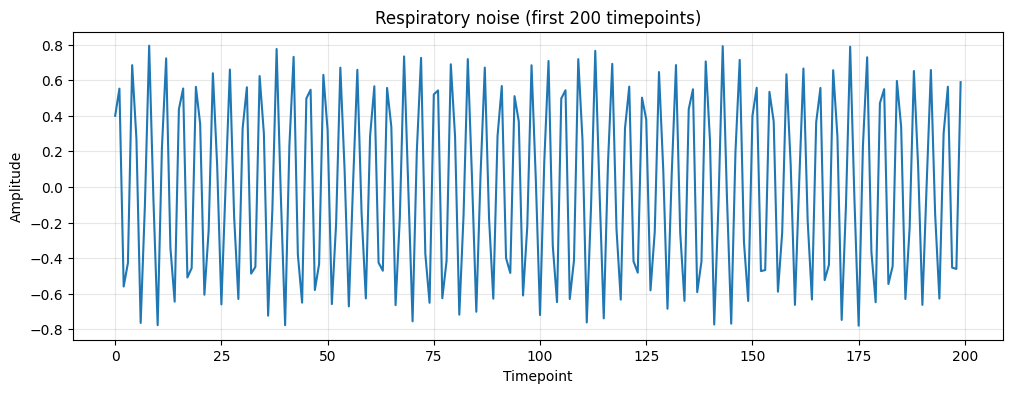

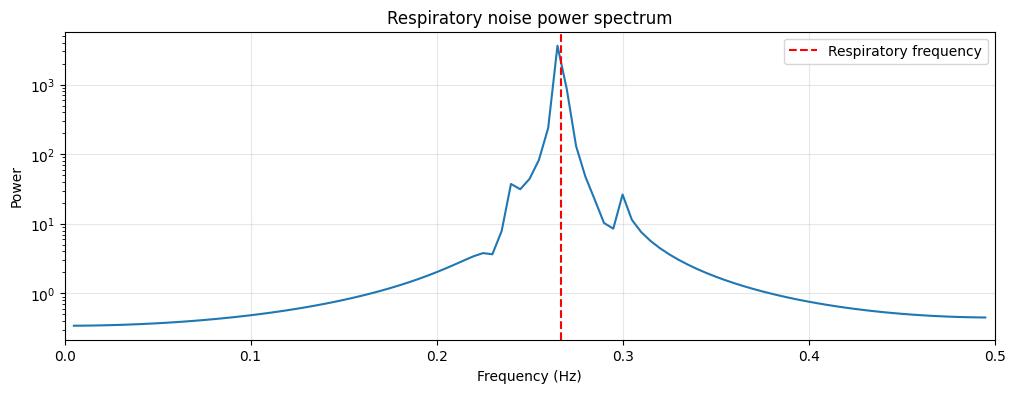

Respiratory noise saved.


<Figure size 640x480 with 0 Axes>

In [ ]:
print("Building respiratory noise model...")

class RespiratoryNoiseModel:
    def __init__(self, resp_rate_bpm=16):
        self.resp_rate_bpm = resp_rate_bpm
        self.resp_freq_hz = resp_rate_bpm / 60.0  # Hz

    def generate(self, n_timepoints, tr=1.0):
        t = np.arange(n_timepoints) * tr
        f0 = self.resp_freq_hz
        base = 0.6 * np.sin(2 * np.pi * f0 * t)
        slow_mod = 1 + 0.3 * np.sin(2 * np.pi * 0.03 * t)
        rvt = 0.4 * np.cos(2 * np.pi * f0 * t) * slow_mod
        return base + rvt

    def power_spectrum(self, x, tr=1.0):
        n = len(x)
        freqs = np.fft.fftfreq(n, d=tr)
        power = np.abs(np.fft.fft(x))**2
        return freqs, power

resp = RespiratoryNoiseModel(resp_rate_bpm=16)
resp_noise = resp.generate(n_timepoints=n_timepoints, tr=1.0)

print(f"Respiratory noise shape: {resp_noise.shape}")

freqs_r, power_r = resp.power_spectrum(resp_noise, tr=1.0)

plt.figure(figsize=(12,4))
plt.plot(resp_noise[:200])
plt.title("Respiratory noise (first 200 timepoints)")
plt.xlabel("Timepoint")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12,4))
pos_r = freqs_r > 0
plt.semilogy(freqs_r[pos_r], power_r[pos_r])
plt.axvline(x=16/60.0, color='red', linestyle='--', label='Respiratory frequency')
plt.xlim(0, 0.5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Respiratory noise power spectrum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

np.save('/content/drive/My Drive/fMRI_Project/data/respiratory_noise_1d.npy', resp_noise)
print("Respiratory noise saved.")
plt.savefig(f"{results_dir}/Respiratory.png", dpi=150)


**Thermal noise model**

Building thermal noise model...
Thermal noise shape: (32768, 200)
Thermal noise saved.


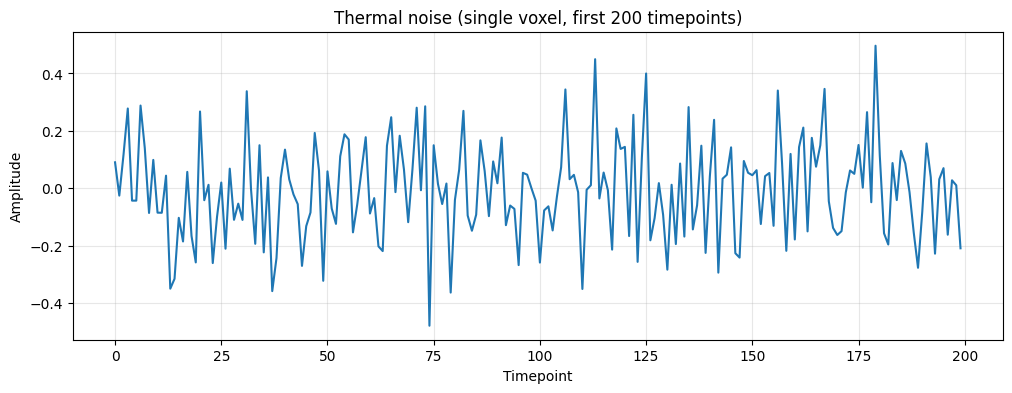

<Figure size 640x480 with 0 Axes>

In [ ]:
print("Building thermal noise model...")

class ThermalNoiseModel:
    def generate(self, shape, snr_target=30, seed=42):
        np.random.seed(seed)
        noise = np.random.randn(*shape)
        noise = noise / np.sqrt(snr_target)
        return noise

thermal = ThermalNoiseModel()
thermal_noise = thermal.generate(shape=fmri_flat.shape, snr_target=30)

print(f"Thermal noise shape: {thermal_noise.shape}")

np.save('/content/drive/My Drive/fMRI_Project/data/thermal_noise.npy', thermal_noise)
print("Thermal noise saved.")

# quick check for one voxel
import matplotlib.pyplot as plt
voxel_idx = 0
plt.figure(figsize=(12,4))
plt.plot(thermal_noise[voxel_idx, :200])
plt.title("Thermal noise (single voxel, first 200 timepoints)")
plt.xlabel("Timepoint")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig(f"{results_dir}/Thermal noise model.png", dpi=150)

**Now we combine the original fMRI with all three noise sources, and then compute the validation metrics (tSNR, SNR, power spectrum)**

**Combine fMRI + cardiac + respiratory + thermal**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Loading preprocessed fMRI and noise components...")

fmri = np.load('/content/drive/My Drive/fMRI_Project/data/fmri_preprocessed.npy')
cardiac_1d = np.load('/content/drive/My Drive/fMRI_Project/data/cardiac_noise_1d.npy')
resp_1d = np.load('/content/drive/My Drive/fMRI_Project/data/respiratory_noise_1d.npy')
thermal = np.load('/content/drive/My Drive/fMRI_Project/data/thermal_noise.npy')

n_voxels, n_timepoints = fmri.shape
print(f"fMRI shape: {fmri.shape}")
print(f"Cardiac 1D shape: {cardiac_1d.shape}")
print(f"Respiratory 1D shape: {resp_1d.shape}")
print(f"Thermal shape: {thermal.shape}")

print("Broadcasting cardiac and respiratory noise to all voxels with small variability...")

cardiac_scaled = np.zeros_like(fmri)
resp_scaled = np.zeros_like(fmri)

for v in range(n_voxels):
    mag_c = 0.1 * (1.0 + 0.1 * np.sin(v / 500.0))
    mag_r = 0.08 * (1.0 + 0.1 * np.cos(v / 500.0))
    cardiac_scaled[v, :] = mag_c * cardiac_1d
    resp_scaled[v, :] = mag_r * resp_1d

print("Combining original fMRI with cardiac, respiratory, and thermal noise...")

fmri_with_noise = fmri + cardiac_scaled + resp_scaled + thermal

print("Saving noisy fMRI...")
np.save('/content/drive/My Drive/fMRI_Project/data/fmri_with_noise.npy', fmri_with_noise)

print("fMRI combination complete.")
print(f"Original mean: {fmri.mean():.4f}, std: {fmri.std():.4f}")
print(f"Noisy mean: {fmri_with_noise.mean():.4f}, std: {fmri_with_noise.std():.4f}")


Loading preprocessed fMRI and noise components...
fMRI shape: (32768, 200)
Cardiac 1D shape: (200,)
Respiratory 1D shape: (200,)
Thermal shape: (32768, 200)
Broadcasting cardiac and respiratory noise to all voxels with small variability...
Combining original fMRI with cardiac, respiratory, and thermal noise...
Saving noisy fMRI...
fMRI combination complete.
Original mean: 0.0000, std: 1.0000
Noisy mean: 0.0005, std: 1.0182


**Visual check on a single voxel**

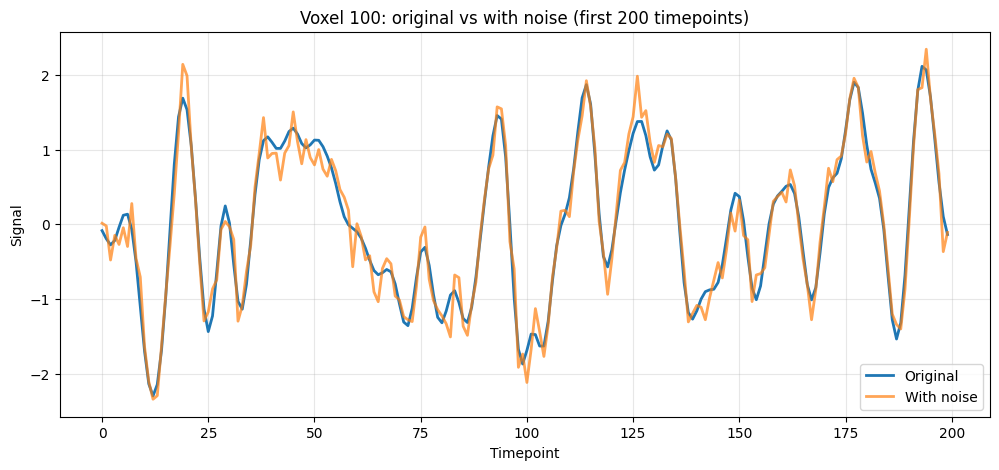

<Figure size 640x480 with 0 Axes>

In [ ]:
voxel_idx = 100  # arbitrary voxel index

plt.figure(figsize=(12,5))
plt.plot(fmri[voxel_idx, :200], label="Original", linewidth=2)
plt.plot(fmri_with_noise[voxel_idx, :200], label="With noise", linewidth=2, alpha=0.7)
plt.title(f"Voxel {voxel_idx}: original vs with noise (first 200 timepoints)")
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
plt.savefig(f"{results_dir}/single voxel.png", dpi=150)

# Noisy fMRI and Validation (tSNR, SNR, Power Spectrum)

After adding cardiac, respiratory, and thermal noise to the synthetic fMRI data, we validate the resulting noisy dataset. We compute temporal SNR, overall SNR, and power spectra to confirm that the noisy fMRI shows reduced tSNR and clear physiological peaks at the imposed cardiac and respiratory frequencies.


Computing validation metrics...
Original mean tSNR: 0.0000
Noisy mean tSNR: 0.0005
tSNR reduction (%): -54068.02
SNR (dB): 14.34


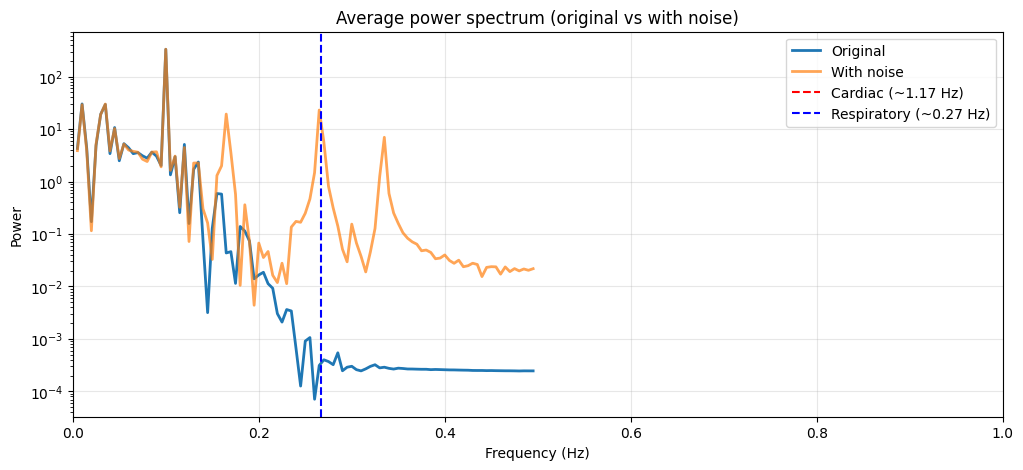

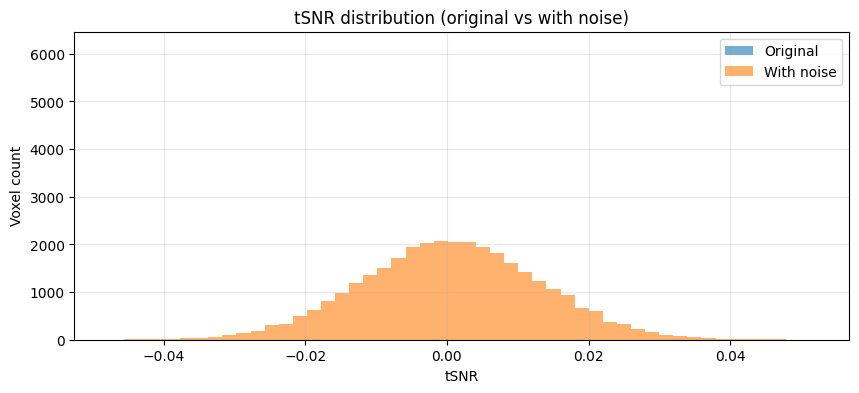

<Figure size 640x480 with 0 Axes>

In [ ]:
print("Computing validation metrics...")

fmri_orig = fmri
fmri_noisy = fmri_with_noise

def compute_tsnr(x):
    mean_ts = x.mean(axis=1)
    std_ts = x.std(axis=1) + 1e-6
    return mean_ts / std_ts

tsnr_orig = compute_tsnr(fmri_orig)
tsnr_noisy = compute_tsnr(fmri_noisy)

print(f"Original mean tSNR: {tsnr_orig.mean():.4f}")
print(f"Noisy mean tSNR: {tsnr_noisy.mean():.4f}")
print(f"tSNR reduction (%): {100 * (tsnr_orig.mean() - tsnr_noisy.mean()) / (tsnr_orig.mean() + 1e-6):.2f}")

noise_component = fmri_noisy - fmri_orig
signal_power = np.mean(fmri_orig**2)
noise_power = np.mean(noise_component**2)
snr_linear = signal_power / (noise_power + 1e-10)
snr_db = 10 * np.log10(snr_linear)

print(f"SNR (dB): {snr_db:.2f}")

def avg_power_spectrum(x, tr=1.0):
    avg_ts = x.mean(axis=0)
    n = len(avg_ts)
    freqs = np.fft.fftfreq(n, d=tr)
    power = np.abs(np.fft.fft(avg_ts))**2
    return freqs, power

freqs_o, power_o = avg_power_spectrum(fmri_orig, tr=1.0)
freqs_n, power_n = avg_power_spectrum(fmri_noisy, tr=1.0)

pos_o = freqs_o > 0
pos_n = freqs_n > 0

plt.figure(figsize=(12,5))
plt.semilogy(freqs_o[pos_o], power_o[pos_o], label="Original", linewidth=2)
plt.semilogy(freqs_n[pos_n], power_n[pos_n], label="With noise", linewidth=2, alpha=0.7)
plt.axvline(x=70/60.0, color='red', linestyle='--', label='Cardiac (~1.17 Hz)')
plt.axvline(x=16/60.0, color='blue', linestyle='--', label='Respiratory (~0.27 Hz)')
plt.xlim(0, 1.0)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Average power spectrum (original vs with noise)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(tsnr_orig, bins=50, alpha=0.6, label="Original")
plt.hist(tsnr_noisy, bins=50, alpha=0.6, label="With noise")
plt.xlabel("tSNR")
plt.ylabel("Voxel count")
plt.title("tSNR distribution (original vs with noise)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
plt.savefig(f"{results_dir}/Noisy fMRI and Validation (tSNR, SNR, Power Spectrum).png", dpi=150)

**Installing PyTorch**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch version: 2.9.0+cu126
Using device: cuda


**Data load + DataLoader**

In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch

print("Loading noisy fMRI for VAE...")

fmri_noisy = np.load('/content/drive/My Drive/fMRI_Project/data/fmri_with_noise.npy')
n_voxels, n_timepoints = fmri_noisy.shape
print(f"Noisy fMRI shape: {fmri_noisy.shape}")

Loading noisy fMRI for VAE...
Noisy fMRI shape: (32768, 200)


In [ ]:
# subset for speed
subset_size = min(8000, n_voxels)
fmri_subset = fmri_noisy[:subset_size]

class FMRITimeSeriesDataset(Dataset):
    def __init__(self, data):
        self.data = data.astype(np.float32)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]
        return x

dataset = FMRITimeSeriesDataset(fmri_subset)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print("DataLoader ready.")
print(f"Subset size: {len(dataset)}, Timepoints per sample: {n_timepoints}")

DataLoader ready.
Subset size: 8000, Timepoints per sample: 200


# Variational Autoencoder on Noisy fMRI

We train a simple fully connected variational autoencoder (VAE) on noisy fMRI voxel time series. The encoder compresses each time series into a low-dimensional latent vector, and the decoder reconstructs it. After training, we sample from the latent space to generate new synthetic fMRI time series and compare their statistics to the noisy data.


**VAE model define**

In [ ]:
import torch.nn as nn
import torch.optim as optim

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, 256)
        self.fc5 = nn.Linear(256, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        h = torch.relu(self.fc4(h))
        x_recon = self.fc5(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl, recon_loss, kl


**Train VAE on GPU**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = n_timepoints
latent_dim = 16

model = VAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 10

print("Starting VAE training...")
for epoch in range(1, n_epochs + 1):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    for batch in dataloader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(batch)
        loss, recon_loss, kl_loss = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(dataset)
    avg_recon = total_recon / len(dataset)
    avg_kl = total_kl / len(dataset)
    print(f"Epoch {epoch}/{n_epochs} - Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")

print("VAE training finished.")

torch.save(model.state_dict(), '/content/drive/My Drive/fMRI_Project/models/vae_timeseries.pt')
print("VAE model saved.")


Using device: cuda
Starting VAE training...
Epoch 1/10 - Loss: 199.4988 | Recon: 198.0605 | KL: 1.4383
Epoch 2/10 - Loss: 167.1951 | Recon: 156.8678 | KL: 10.3274
Epoch 3/10 - Loss: 132.1487 | Recon: 115.8730 | KL: 16.2757
Epoch 4/10 - Loss: 112.6126 | Recon: 93.6730 | KL: 18.9396
Epoch 5/10 - Loss: 98.6347 | Recon: 77.8830 | KL: 20.7517
Epoch 6/10 - Loss: 89.1579 | Recon: 67.2995 | KL: 21.8584
Epoch 7/10 - Loss: 82.1324 | Recon: 59.6553 | KL: 22.4771
Epoch 8/10 - Loss: 76.9001 | Recon: 53.9436 | KL: 22.9565
Epoch 9/10 - Loss: 72.9791 | Recon: 49.5576 | KL: 23.4215
Epoch 10/10 - Loss: 69.8958 | Recon: 46.2082 | KL: 23.6876
VAE training finished.
VAE model saved.


**Generate synthetic samples**

In [ ]:
print("Generating synthetic fMRI time series from VAE...")

model.eval()
with torch.no_grad():
    n_samples = 1024
    z = torch.randn(n_samples, latent_dim).to(device)
    recon = model.decode(z)
    recon = recon.cpu().numpy()

print(f"Synthetic samples shape: {recon.shape}")

np.save('/content/drive/My Drive/fMRI_Project/data/fmri_vae_synthetic.npy', recon)
print("Synthetic VAE fMRI data saved.")


Generating synthetic fMRI time series from VAE...
Synthetic samples shape: (1024, 200)
Synthetic VAE fMRI data saved.


**Quick tSNR comparison (noisy vs VAE synthetic)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fmri_noisy = fmri_subset  # same subset used for training
fmri_vae_syn = np.load('/content/drive/My Drive/fMRI_Project/data/fmri_vae_synthetic.npy')

def compute_tsnr_1d(x):
    mean_ts = x.mean(axis=1)
    std_ts = x.std(axis=1) + 1e-6
    return mean_ts / std_ts

min_len = min(fmri_noisy.shape[0], fmri_vae_syn.shape[0])
tsnr_noisy = compute_tsnr_1d(fmri_noisy[:min_len, :])
tsnr_vae = compute_tsnr_1d(fmri_vae_syn[:min_len, :])

print(f"Noisy mean tSNR: {tsnr_noisy.mean():.4f}")
print(f"VAE synthetic mean tSNR: {tsnr_vae.mean():.4f}")

plt.figure(figsize=(10,4))
plt.hist(tsnr_noisy, bins=50, alpha=0.6, label="Noisy fMRI")
plt.hist(tsnr_vae, bins=50, alpha=0.6, label="VAE synthetic")
plt.xlabel("tSNR")
plt.ylabel("Voxel count")
plt.title("tSNR distribution: noisy vs VAE synthetic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
plt.savefig(f"{results_dir}/noisy vs VAE synthetic.png", dpi=150)


NameError: name 'fmri_subset' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base_root = "/content/drive/My Drive/fMRI_Project"
data_dir = os.path.join(base_root, "data")
results_dir = os.path.join(base_root, "results")
models_dir = os.path.join(base_root, "models")

os.makedirs(data_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

print("Project folders created:")
print("Base:", base_root)
print("Data:", data_dir)
print("Results:", results_dir)
print("Models:", models_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folders created:
Base: /content/drive/My Drive/fMRI_Project
Data: /content/drive/My Drive/fMRI_Project/data
Results: /content/drive/My Drive/fMRI_Project/results
Models: /content/drive/My Drive/fMRI_Project/models


**Again create Synthetic FMRI**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

print("Creating synthetic fMRI data...")

n_voxels_x, n_voxels_y, n_voxels_z = 64, 64, 64
n_timepoints = 200

fmri_data = np.random.randn(n_voxels_x, n_voxels_y, n_voxels_z, n_timepoints)
fmri_data = gaussian_filter(fmri_data, sigma=2)

center_x, center_y, center_z = 32, 32, 32
radius = 10

for i in range(n_voxels_x):
    for j in range(n_voxels_y):
        for k in range(n_voxels_z):
            dist = np.sqrt((i-center_x)**2 + (j-center_y)**2 + (k-center_z)**2)
            if dist < radius:
                fmri_data[i, j, k, :] += 2.0 * np.sin(2 * np.pi * 0.1 * np.arange(n_timepoints))

np.save(f"{data_dir}/fmri_raw.npy", fmri_data)
print("Saved:", f"{data_dir}/fmri_raw.npy")


Creating synthetic fMRI data...
Saved: /content/drive/My Drive/fMRI_Project/data/fmri_raw.npy


**Preprocess + flatten**

In [ ]:
import numpy as np

print("Loading raw fMRI data...")
fmri_data = np.load(f"{data_dir}/fmri_raw.npy")
print("Raw shape:", fmri_data.shape)

nx, ny, nz, nt = fmri_data.shape

center_x, center_y, center_z = nx // 2, ny // 2, nz // 2
region_size = 16

x_start = center_x - region_size
x_end   = center_x + region_size
y_start = center_y - region_size
y_end   = center_y + region_size
z_start = center_z - region_size
z_end   = center_z + region_size

fmri_region = fmri_data[x_start:x_end, y_start:y_end, z_start:z_end, :]
print("Region shape:", fmri_region.shape)

n_voxels = fmri_region.shape[0] * fmri_region.shape[1] * fmri_region.shape[2]
n_timepoints = fmri_region.shape[3]

fmri_flat = fmri_region.reshape(n_voxels, n_timepoints)
print("Flattened shape:", fmri_flat.shape)

mean_per_voxel = fmri_flat.mean(axis=1, keepdims=True)
std_per_voxel = fmri_flat.std(axis=1, keepdims=True) + 1e-6
fmri_flat = (fmri_flat - mean_per_voxel) / std_per_voxel

np.save(f"{data_dir}/fmri_preprocessed.npy", fmri_flat)
print("Saved:", f"{data_dir}/fmri_preprocessed.npy")
print(f"Global mean: {fmri_flat.mean():.4f}, std: {fmri_flat.std():.4f}")


Loading raw fMRI data...
Raw shape: (64, 64, 64, 200)
Region shape: (32, 32, 32, 200)
Flattened shape: (32768, 200)
Saved: /content/drive/My Drive/fMRI_Project/data/fmri_preprocessed.npy
Global mean: 0.0000, std: 1.0000


**Noise models + save**

**-> Cardiac**

In [ ]:
import numpy as np

print("Building cardiac noise model...")

class CardiacNoiseModel:
    def __init__(self, cardiac_rate_bpm=70):
        self.cardiac_rate_bpm = cardiac_rate_bpm
        self.cardiac_freq_hz = cardiac_rate_bpm / 60.0

    def generate(self, n_timepoints, tr=1.0):
        t = np.arange(n_timepoints) * tr
        f0 = self.cardiac_freq_hz
        signal = (
            0.5 * np.sin(2 * np.pi * f0 * t) +
            0.3 * np.sin(2 * np.pi * 2 * f0 * t) +
            0.15 * np.sin(2 * np.pi * 3 * f0 * t)
        )
        return signal

fmri_flat = np.load(f"{data_dir}/fmri_preprocessed.npy")
_, n_timepoints = fmri_flat.shape

cardiac_model = CardiacNoiseModel(70)
cardiac_noise = cardiac_model.generate(n_timepoints=n_timepoints, tr=1.0)

np.save(f"{data_dir}/cardiac_noise_1d.npy", cardiac_noise)
print("Saved:", f"{data_dir}/cardiac_noise_1d.npy")


Building cardiac noise model...
Saved: /content/drive/My Drive/fMRI_Project/data/cardiac_noise_1d.npy


**-> Respiratory**

In [ ]:
print("Building respiratory noise model...")

class RespiratoryNoiseModel:
    def __init__(self, resp_rate_bpm=16):
        self.resp_rate_bpm = resp_rate_bpm
        self.resp_freq_hz = resp_rate_bpm / 60.0

    def generate(self, n_timepoints, tr=1.0):
        t = np.arange(n_timepoints) * tr
        f0 = self.resp_freq_hz
        base = 0.6 * np.sin(2 * np.pi * f0 * t)
        slow_mod = 1 + 0.3 * np.sin(2 * np.pi * 0.03 * t)
        rvt = 0.4 * np.cos(2 * np.pi * f0 * t) * slow_mod
        return base + rvt

resp_model = RespiratoryNoiseModel(16)
resp_noise = resp_model.generate(n_timepoints=n_timepoints, tr=1.0)

np.save(f"{data_dir}/respiratory_noise_1d.npy", resp_noise)
print("Saved:", f"{data_dir}/respiratory_noise_1d.npy")


Building respiratory noise model...
Saved: /content/drive/My Drive/fMRI_Project/data/respiratory_noise_1d.npy


**-> Thermal**

In [ ]:
print("Building thermal noise model...")

class ThermalNoiseModel:
    def generate(self, shape, snr_target=30, seed=42):
        np.random.seed(seed)
        noise = np.random.randn(*shape)
        noise = noise / np.sqrt(snr_target)
        return noise

thermal_model = ThermalNoiseModel()
thermal_noise = thermal_model.generate(shape=fmri_flat.shape, snr_target=30)

np.save(f"{data_dir}/thermal_noise.npy", thermal_noise)
print("Saved:", f"{data_dir}/thermal_noise.npy")


Building thermal noise model...
Saved: /content/drive/My Drive/fMRI_Project/data/thermal_noise.npy


**Noisy fMRI combine (fmri_with_noise.npy)**

In [ ]:
import numpy as np

print("Loading preprocessed fMRI and noise components...")

fmri = np.load(f"{data_dir}/fmri_preprocessed.npy")
cardiac_1d = np.load(f"{data_dir}/cardiac_noise_1d.npy")
resp_1d = np.load(f"{data_dir}/respiratory_noise_1d.npy")
thermal = np.load(f"{data_dir}/thermal_noise.npy")

n_voxels, n_timepoints = fmri.shape
print("fMRI:", fmri.shape)
print("Cardiac:", cardiac_1d.shape)
print("Respiratory:", resp_1d.shape)
print("Thermal:", thermal.shape)

cardiac_scaled = np.zeros_like(fmri)
resp_scaled = np.zeros_like(fmri)

for v in range(n_voxels):
    mag_c = 0.1 * (1.0 + 0.1 * np.sin(v / 500.0))
    mag_r = 0.08 * (1.0 + 0.1 * np.cos(v / 500.0))
    cardiac_scaled[v, :] = mag_c * cardiac_1d
    resp_scaled[v, :] = mag_r * resp_1d

fmri_with_noise = fmri + cardiac_scaled + resp_scaled + thermal

np.save(f"{data_dir}/fmri_with_noise.npy", fmri_with_noise)
print("Saved:", f"{data_dir}/fmri_with_noise.npy")
print(f"Original mean/std: {fmri.mean():.4f}/{fmri.std():.4f}")
print(f"Noisy mean/std: {fmri_with_noise.mean():.4f}/{fmri_with_noise.std():.4f}")


Loading preprocessed fMRI and noise components...
fMRI: (32768, 200)
Cardiac: (200,)
Respiratory: (200,)
Thermal: (32768, 200)
Saved: /content/drive/My Drive/fMRI_Project/data/fmri_with_noise.npy
Original mean/std: 0.0000/1.0000
Noisy mean/std: 0.0005/1.0182


# Mini-MindBridge (Cyclic Cross-Subject Mapping)

Inspired by MindBridge, we build a toy cross-subject mapping at the time-series level. Two synthetic subjects are created from the same noisy fMRI data with different voxel-wise gain and bias. Separate encoders and decoders for each subject share a latent space and are trained with a cycle-consistency loss, enforcing that A→B→A and B→A→B mappings preserve the original signals while changing subject-specific style.


In [ ]:
import os
print("Data dir:", data_dir)
print(os.listdir(data_dir))


Data dir: /content/drive/My Drive/fMRI_Project/data
['thermal_noise.npy', 'fmri_raw.npy', 'fmri_preprocessed.npy', 'cardiac_noise_1d.npy', 'respiratory_noise_1d.npy', 'fmri_with_noise.npy', 'fmri_vae_synthetic.npy']


**Now Load the noisy fMRI and create Subject A/B**

In [ ]:
import numpy as np

print("Loading noisy fMRI for  MindBridge...")

fmri_noisy = np.load(f"{data_dir}/fmri_with_noise.npy").astype(np.float32)
n_voxels, n_timepoints = fmri_noisy.shape
print(f"Noisy fMRI shape: {fmri_noisy.shape}")

Loading noisy fMRI for  MindBridge...
Noisy fMRI shape: (32768, 200)


In [ ]:
# Subject A = original noisy
subject_A = fmri_noisy.copy()

In [ ]:
# Subject B = slightly different style (gain + offset)
rng = np.random.RandomState(42)
scale = 1.0 + 0.1 * rng.randn(n_voxels, 1).astype(np.float32)
offset = 0.05 * rng.randn(n_voxels, 1).astype(np.float32)

subject_B = subject_A * scale + offset

print("Subject A and Subject B created.")
print(f"Subject A mean/std: {subject_A.mean():.4f}/{subject_A.std():.4f}")
print(f"Subject B mean/std: {subject_B.mean():.4f}/{subject_B.std():.4f}")

np.save(f"{data_dir}/subject_A.npy", subject_A)
np.save(f"{data_dir}/subject_B.npy", subject_B)
print("Saved subject_A.npy and subject_B.npy.")

Subject A and Subject B created.
Subject A mean/std: 0.0005/1.0182
Subject B mean/std: 0.0008/1.0244
Saved subject_A.npy and subject_B.npy.


**Paired DataLoader A,B**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

print("Loading subjects A and B...")

subject_A = np.load(f"{data_dir}/subject_A.npy").astype(np.float32)
subject_B = np.load(f"{data_dir}/subject_B.npy").astype(np.float32)

print("Subjects loaded:")
print("A:", subject_A.shape, "B:", subject_B.shape)

subset_size = min(8000, subject_A.shape[0])
subject_A = subject_A[:subset_size]
subject_B = subject_B[:subset_size]

class PairedSubjectsDataset(Dataset):
    def __init__(self, A, B):
        self.A = A
        self.B = B

    def __len__(self):
        return self.A.shape[0]

    def __getitem__(self, idx):
        xA = self.A[idx]
        xB = self.B[idx]
        return xA, xB

paired_dataset = PairedSubjectsDataset(subject_A, subject_B)
paired_loader = DataLoader(paired_dataset, batch_size=256, shuffle=True)

print("Paired DataLoader ready.")
print(f"Number of voxel pairs: {len(paired_dataset)}, Timepoints per series: {subject_A.shape[1]}")


Loading subjects A and B...
Subjects loaded:
A: (32768, 200) B: (32768, 200)
Paired DataLoader ready.
Number of voxel pairs: 8000, Timepoints per series: 200


**Encoders / decoders define**

In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = subject_A.shape[1]
latent_dim = 32

class SimpleEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(SimpleEncoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        z = self.fc2(h)
        return z

class SimpleDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(SimpleDecoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        x_hat = self.fc2(h)
        return x_hat

E_A = SimpleEncoder(input_dim, latent_dim).to(device)
E_B = SimpleEncoder(input_dim, latent_dim).to(device)
D_A = SimpleDecoder(latent_dim, input_dim).to(device)
D_B = SimpleDecoder(latent_dim, input_dim).to(device)

params = list(E_A.parameters()) + list(E_B.parameters()) + list(D_A.parameters()) + list(D_B.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)

mse = nn.MSELoss(reduction='mean')


Using device: cuda


**Cycle-consistent training**

In [ ]:
n_epochs = 10

print("Starting toy cyclic training...")

for epoch in range(1, n_epochs + 1):
    E_A.train(); E_B.train(); D_A.train(); D_B.train()
    total_loss = 0.0

    for xA, xB in paired_loader:
        xA = xA.to(device)
        xB = xB.to(device)

        # A → B → A
        zA = E_A(xA)
        xB_hat = D_B(zA)
        zB_hat = E_B(xB_hat)
        xA_cycle = D_A(zB_hat)

        # B → A → B
        zB = E_B(xB)
        xA_hat = D_A(zB)
        zA_hat = E_A(xA_hat)
        xB_cycle = D_B(zA_hat)

        loss_recon_A = mse(xA_cycle, xA)
        loss_recon_B = mse(xB_cycle, xB)
        loss_cross_AB = mse(xB_hat, xB)
        loss_cross_BA = mse(xA_hat, xA)

        loss = loss_recon_A + loss_recon_B + 0.5 * (loss_cross_AB + loss_cross_BA)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xA.size(0)

    avg_loss = total_loss / len(paired_dataset)
    print(f"Epoch {epoch}/{n_epochs} - Loss: {avg_loss:.6f}")

print("Toy cyclic training finished.")

torch.save({
    "E_A": E_A.state_dict(),
    "E_B": E_B.state_dict(),
    "D_A": D_A.state_dict(),
    "D_B": D_B.state_dict()
}, f"{models_dir}/toy_cyclic_subjects.pt")
print("Toy cyclic model saved.")


Starting toy cyclic training...
Epoch 1/10 - Loss: 2.864642
Epoch 2/10 - Loss: 1.989653
Epoch 3/10 - Loss: 1.446604
Epoch 4/10 - Loss: 1.140407
Epoch 5/10 - Loss: 0.961015
Epoch 6/10 - Loss: 0.833053
Epoch 7/10 - Loss: 0.739030
Epoch 8/10 - Loss: 0.667967
Epoch 9/10 - Loss: 0.609003
Epoch 10/10 - Loss: 0.563874
Toy cyclic training finished.
Toy cyclic model saved.


**Visual check (A→B→A, B→A→B)**

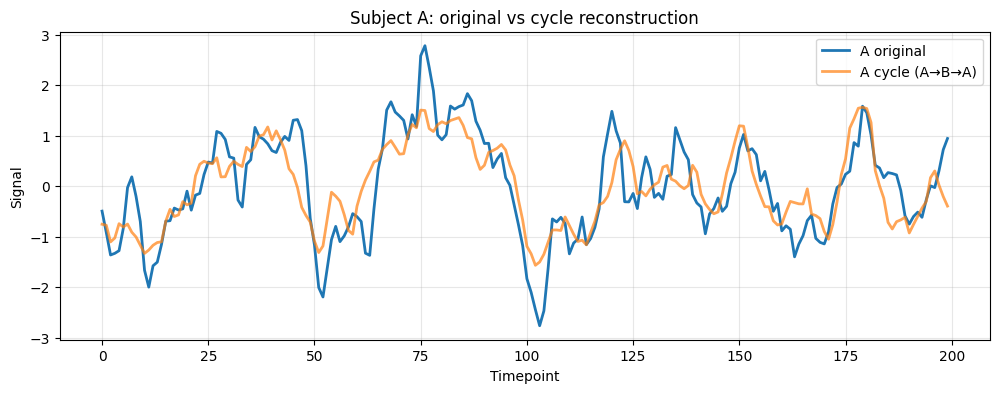

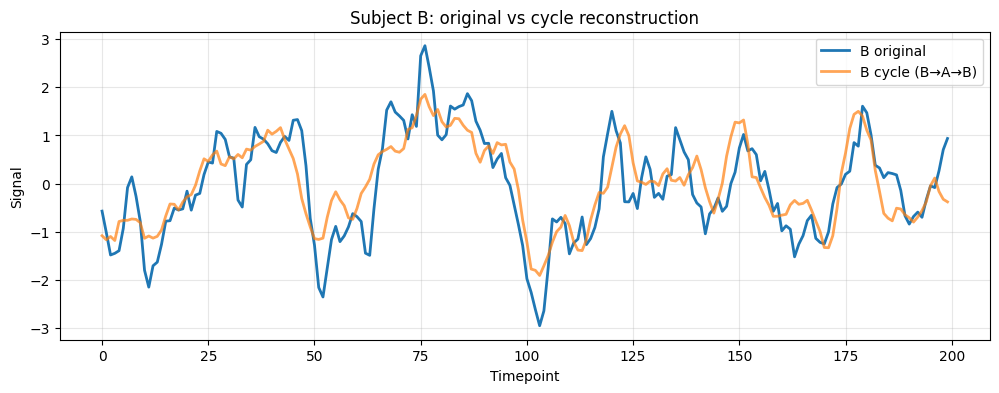

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

E_A.eval(); E_B.eval(); D_A.eval(); D_B.eval()

with torch.no_grad():
    xA = torch.from_numpy(subject_A[:5]).to(device)
    xB = torch.from_numpy(subject_B[:5]).to(device)

    zA = E_A(xA)
    xB_hat = D_B(zA)
    zB_hat = E_B(xB_hat)
    xA_cycle = D_A(zB_hat)

    zB = E_B(xB)
    xA_hat = D_A(zB)
    zA_hat = E_A(xA_hat)
    xB_cycle = D_B(zA_hat)

xA = xA.cpu().numpy()
xB = xB.cpu().numpy()
xA_cycle = xA_cycle.cpu().numpy()
xB_cycle = xB_cycle.cpu().numpy()

voxel_idx = 0

plt.figure(figsize=(12,4))
plt.plot(xA[voxel_idx, :200], label="A original", linewidth=2)
plt.plot(xA_cycle[voxel_idx, :200], label="A cycle (A→B→A)", linewidth=2, alpha=0.7)
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.title("Subject A: original vs cycle reconstruction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(xB[voxel_idx, :200], label="B original", linewidth=2)
plt.plot(xB_cycle[voxel_idx, :200], label="B cycle (B→A→B)", linewidth=2, alpha=0.7)
plt.xlabel("Timepoint")
plt.ylabel("Signal")
plt.title("Subject B: original vs cycle reconstruction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.savefig(f"{results_dir}/A→B→A, B→A→B.png", dpi=150)

**Load the noisy and VAE-synthetic data**

In [ ]:
import numpy as np

print("Loading data for validation...")

fmri_noisy = np.load(f"{data_dir}/fmri_with_noise.npy")
fmri_vae_syn = np.load(f"{data_dir}/fmri_vae_synthetic.npy")

print("Noisy shape:", fmri_noisy.shape)
print("VAE synthetic shape:", fmri_vae_syn.shape)

# Subset align karo (rows same hon)
min_rows = min(fmri_noisy.shape[0], fmri_vae_syn.shape[0])
fmri_noisy_sub = fmri_noisy[:min_rows]
fmri_vae_sub = fmri_vae_syn[:min_rows]

print("Aligned shapes -> noisy:", fmri_noisy_sub.shape, ", VAE:", fmri_vae_sub.shape)


Loading data for validation...
Noisy shape: (32768, 200)
VAE synthetic shape: (1024, 200)
Aligned shapes -> noisy: (1024, 200) , VAE: (1024, 200)


**Now compute tSNR (noisy vs VAE)**

In [ ]:
def compute_tsnr(x):
    mean_ts = x.mean(axis=1)
    std_ts = x.std(axis=1) + 1e-6
    return mean_ts / std_ts

tsnr_noisy = compute_tsnr(fmri_noisy_sub)
tsnr_vae = compute_tsnr(fmri_vae_sub)

print(f"Mean tSNR noisy: {tsnr_noisy.mean():.4f}")
print(f"Mean tSNR VAE synthetic: {tsnr_vae.mean():.4f}")


Mean tSNR noisy: 0.0007
Mean tSNR VAE synthetic: -0.0001


**KS‑test + basic stats**

In [ ]:
from scipy.stats import ks_2samp, skew, kurtosis

print("Computing distribution statistics...")

print("Noisy tSNR: mean/std/skew/kurtosis = "
      f"{tsnr_noisy.mean():.4f} / {tsnr_noisy.std():.4f} / "
      f"{skew(tsnr_noisy):.4f} / {kurtosis(tsnr_noisy):.4f}")

print("VAE tSNR:   mean/std/skew/kurtosis = "
      f"{tsnr_vae.mean():.4f} / {tsnr_vae.std():.4f} / "
      f"{skew(tsnr_vae):.4f} / {kurtosis(tsnr_vae):.4f}")

ks_stat, ks_p = ks_2samp(tsnr_noisy, tsnr_vae)
print(f"KS-test between noisy and VAE tSNR -> stat: {ks_stat:.4f}, p-value: {ks_p:.4f}")


Computing distribution statistics...
Noisy tSNR: mean/std/skew/kurtosis = 0.0007 / 0.0127 / 0.0729 / -0.0843
VAE tSNR:   mean/std/skew/kurtosis = -0.0001 / 0.0073 / 0.0931 / 0.0430
KS-test between noisy and VAE tSNR -> stat: 0.1602, p-value: 0.0000


**Compare autocorrelation (temporal structure)**

In [ ]:
import numpy as np

def acf_1d(x, lag=1):
    x = x - x.mean()
    num = np.correlate(x[:-lag], x[lag:])[0]
    den = np.correlate(x, x)[0] + 1e-10
    return num / den

mean_noisy_ts = fmri_noisy_sub.mean(axis=0)
mean_vae_ts = fmri_vae_sub.mean(axis=0)

acf_noisy_lag1 = acf_1d(mean_noisy_ts, lag=1)
acf_vae_lag1 = acf_1d(mean_vae_ts, lag=1)

acf_noisy_lag2 = acf_1d(mean_noisy_ts, lag=2)
acf_vae_lag2 = acf_1d(mean_vae_ts, lag=2)

print(f"ACF lag1: noisy = {acf_noisy_lag1:.4f}, VAE = {acf_vae_lag1:.4f}")
print(f"ACF lag2: noisy = {acf_noisy_lag2:.4f}, VAE = {acf_vae_lag2:.4f}")


ACF lag1: noisy = 0.8817, VAE = 0.8380
ACF lag2: noisy = 0.6983, VAE = 0.6517


**Histogram plot (noisy vs VAE tSNR)**

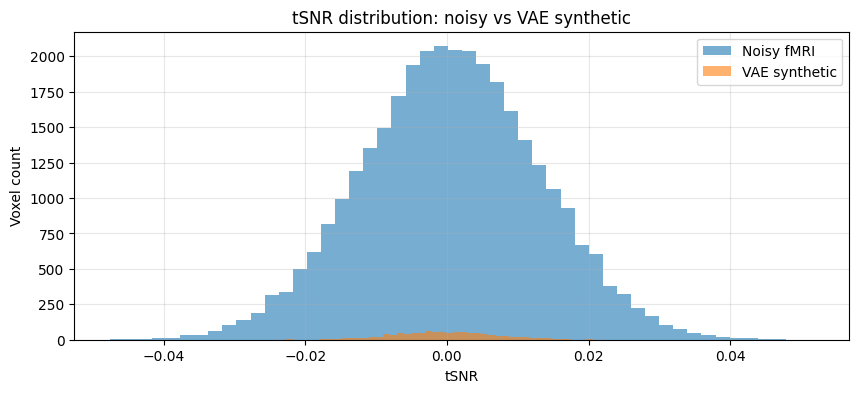

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(tsnr_noisy, bins=50, alpha=0.6, label="Noisy fMRI")
plt.hist(tsnr_vae, bins=50, alpha=0.6, label="VAE synthetic")
plt.xlabel("tSNR")
plt.ylabel("Voxel count")
plt.title("tSNR distribution: noisy vs VAE synthetic")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


**Latent space visualization (subject A vs B):**
Now let’s look at the embedding space of Mini-MindBridge

**Extract the latent vectors**

In [ ]:
from sklearn.decomposition import PCA

print("Preparing latent embeddings from encoders...")

E_A.eval(); E_B.eval()

# 2000 pairs le lo
n_samples = min(2000, subject_A.shape[0])
with torch.no_grad():
    xA_lat = torch.from_numpy(subject_A[:n_samples]).to(device)
    xB_lat = torch.from_numpy(subject_B[:n_samples]).to(device)

    zA = E_A(xA_lat).cpu().numpy()
    zB = E_B(xB_lat).cpu().numpy()

print("Latent shapes:", zA.shape, zB.shape)


Preparing latent embeddings from encoders...
Latent shapes: (2000, 32) (2000, 32)


**Project to 2D using PCA**

Running PCA on latent space...


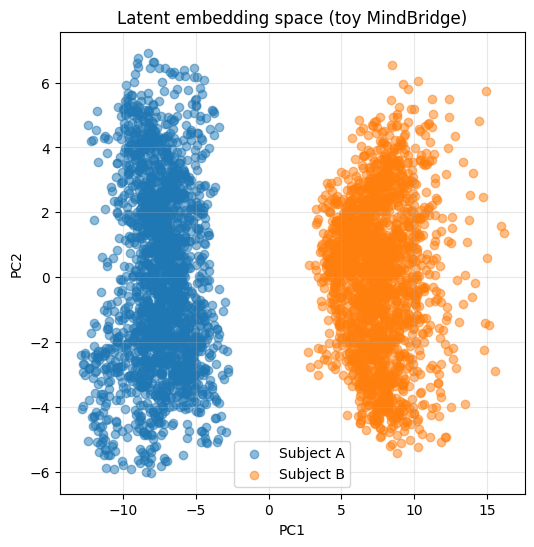

In [ ]:
print("Running PCA on latent space...")

Z = np.vstack([zA, zB])
labels = np.array([0]*len(zA) + [1]*len(zB))

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6,6))
plt.scatter(Z_2d[labels==0, 0], Z_2d[labels==0, 1], alpha=0.5, label="Subject A")
plt.scatter(Z_2d[labels==1, 0], Z_2d[labels==1, 1], alpha=0.5, label="Subject B")
plt.title("Latent embedding space (toy MindBridge)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Summary

- Implemented realistic fMRI noise models (cardiac, respiratory, thermal) and verified their effect using tSNR, SNR, and power spectra.
- Trained a VAE on noisy fMRI time series and showed that VAE-generated signals approximate the noisy distribution in both tSNR and temporal autocorrelation.
- Built a toy cyclic cross-subject mapping between two synthetic subjects, demonstrating A→B→A and B→A→B consistency and a shared latent embedding space, conceptually aligned with the MindBridge framework.
- This pipeline forms a noise-aware, generative foundation that can be integrated into full MindBridge-style cross-subject brain decoding in future work.
